## 패키지 설치

In [1]:
# %conda install kagglehub

In [2]:
import subprocess, sys

# ─────────────────────────────────────────────
# numpy, PyTorch, matplotlib 설치
# ─────────────────────────────────────────────
packages = ["numpy", "torch", "matplotlib"]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
    )

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

print(f"✅ numpy     {np.__version__}")
print(f"✅ pandas     {pd.__version__}")
print(f"✅ torch     {torch.__version__}")
print(f"✅ matplotlib {matplotlib.__version__}")

✅ numpy     1.26.4
✅ pandas     3.0.1
✅ torch     2.10.0
✅ matplotlib 3.10.8


# 데이터 로드 및 확인
### E-Commerce Customer Churn

| 항목 | 내용 |
|---|---|
| 데이터 크기 | 5,630행 × 20컬럼 |
| **타겟 변수** | `Churn` (0 = 유지, 1 = 이탈) |
| 이탈 비율 | 약 16.8% (클래스 불균형 주의) |
| 주요 피처 | Tenure, SatisfactionScore, Complain, DaySinceLastOrder, CashbackAmount 등 |

In [3]:
# 데이터 기본 정보 확인
df = pd.read_csv("data/E Commerce Dataset.csv")
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

(5630, 20)

In [23]:
# 컬럼별 항목(개수, 평균, 중앙, 최소 ~ 최대값)
df.describe().T.style.format("{:.2f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.00,52815.50,1625.39,50001.00,51408.25,52815.50,54222.75,55630.00
Churn,5630.00,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,5630.00,10.13,8.36,0.00,3.00,9.00,15.00,61.00
CityTier,5630.00,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,5630.00,15.57,8.35,5.00,9.00,14.00,20.00,127.00
HourSpendOnApp,5630.00,2.93,0.71,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.00,3.69,1.02,1.00,3.00,4.00,4.00,6.00
SatisfactionScore,5630.00,3.07,1.38,1.00,2.00,3.00,4.00,5.00
NumberOfAddress,5630.00,4.21,2.58,1.00,2.00,3.00,6.00,22.00
Complain,5630.00,0.28,0.45,0.00,0.00,0.00,1.00,1.00


In [5]:
# 범주형, 수치형 데이터 확인

import pandas as pd
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 범주형 데이터 
cat_summary = pd.DataFrame({
    "컬럼명": categorical_cols,
    "고유값 개수": [df[col].nunique() for col in categorical_cols],
    "고유값 목록": [df[col].unique().tolist() for col in categorical_cols]
})
# 왼쪽 정렬
cat_styled = cat_summary.style.set_properties(**{'text-align': 'left'})\
                              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])


print("📂 범주형 컬럼 (Categorical) — 총 {}개".format(len(categorical_cols)))
display(cat_styled)


# 수치형 데이터
num_summary = pd.DataFrame({
        "컬럼명": numerical_cols,
        "결측치": [df[col].isnull().sum() for col in numerical_cols],
})
# 왼쪽 정렬 
num_styled = num_summary.style.set_properties(**{'text-align': 'left'})\
                              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
print("🔢 수치형 컬럼 (Numerical) — 총 {}개".format(len(numerical_cols)))
display(num_styled)

📂 범주형 컬럼 (Categorical) — 총 5개


,컬럼명,고유값 개수,고유값 목록
0,PreferredLoginDevice,3,"['Mobile Phone', 'Phone', 'Computer']"
1,PreferredPaymentMode,7,"['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD', 'Credit Card']"
2,Gender,2,"['Female', 'Male']"
3,PreferedOrderCat,6,"['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']"
4,MaritalStatus,3,"['Single', 'Divorced', 'Married']"


🔢 수치형 컬럼 (Numerical) — 총 15개


,컬럼명,결측치
0,CustomerID,0
1,Churn,0
2,Tenure,264
3,CityTier,0
4,WarehouseToHome,251
5,HourSpendOnApp,255
6,NumberOfDeviceRegistered,0
7,SatisfactionScore,0
8,NumberOfAddress,0
9,Complain,0


# 데이터 분리 

- Train / Validation / Test Split (60 / 20 / 20) <br>
- 타겟 변수: `Churn` (0=유지, 1=이탈)  
- 클래스 불균형 유지를 위해 모든 분할에 `stratify=y` 적용

In [31]:
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────────────────────────────
# Train / Validation / Test  =  60% / 20% / 20%
# ─────────────────────────────────────────────────────────────────────
SEED = 42

# CustomerID 제거, 타겟 분리
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

# Step 1: 전체 → Train(60%) + Temp(40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=SEED
)

# Step 2: Temp(40%) → Validation(20%) + Test(20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 40% × 50% = 20%
    stratify=y_temp,
    random_state=SEED
)

print("🎯 타겟 변수: Churn  (0=유지, 1=이탈)")
print(f"   전체 이탈률: {y.mean()*100:.1f}%\n")
print(f"{'세트':<9} {'행 수':>8} {'이탈(1)':>8} {'이탈률':>7}")
print("─"*42)
for name, y in [("Train(60%)", y_train), ("Val(20%)",  y_val), ("Test(20%)",  y_test)]:
    print(f"{name:<12} {len(y):>8,} {y.sum():>8} {y.mean()*100:>8.1f}%")
print(f"{'전체':<11} {len(y):>8,} {y.sum():>8} {y.mean()*100:>8.1f}%")
print()
print("🧨피처 수: {X_train.shape[1]}개")
print(f"  피처 목록:\n {X_train.columns}")

🎯 타겟 변수: Churn  (0=유지, 1=이탈)
   전체 이탈률: 16.8%

세트             행 수    이탈(1)     이탈률
──────────────────────────────────────────
Train(60%)      3,378      569     16.8%
Val(20%)        1,126      190     16.9%
Test(20%)       1,126      189     16.8%
전체             1,126      189     16.8%

🧨피처 수: {X_train.shape[1]}개
  피처 목록:
 Index(['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome',
       'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount', 'OrderCount_log',
       'CouponUsed_log'],
      dtype='str')


# 범주형 데이터 정제 및 통합

In [7]:
# 범주형 데이터 정제 및 통합

print("정제 전 고유값:")
print(f"  PreferredLoginDevice : {sorted(df['PreferredLoginDevice'].unique())}")
print(f"  PreferedOrderCat     : {sorted(df['PreferedOrderCat'].unique())}")
print(f"  PreferredPaymentMode : {sorted(df['PreferredPaymentMode'].unique())}")

# ── PreferredLoginDevice: Mobile Phone → Phone 으로 통일 ─────────────
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})

# ── PreferedOrderCat: Mobile Phone → Mobile 으로 통일 ────────────────
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile Phone": "Mobile"})

# ── PreferredPaymentMode: 중복 표기 통일 ─────────────────────────────
#    COD + Cash on Delivery → "COD"         (약어로 통일)
#    CC  + Credit Card      → "Credit Card" (정식 명칭으로 통일)
#    최종 5종: COD / Credit Card / Debit Card / E wallet / UPI
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "Cash on Delivery": "COD",
    "CC"              : "Credit Card",
})

print("\n정제 후 고유값:")
print(f"  PreferredLoginDevice : {sorted(df['PreferredLoginDevice'].unique())}")
print(f"  PreferedOrderCat     : {sorted(df['PreferedOrderCat'].unique())}")
print(f"  PreferredPaymentMode : {sorted(df['PreferredPaymentMode'].unique())}")
print("\n✅ 카테고리 정제 완료")

정제 전 고유값:
  PreferredLoginDevice : ['Computer', 'Mobile Phone', 'Phone']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']
  PreferredPaymentMode : ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']

정제 후 고유값:
  PreferredLoginDevice : ['Computer', 'Phone']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Others']
  PreferredPaymentMode : ['COD', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']

✅ 카테고리 정제 완료


# 데이터 전처리
## 1. 중복 데이터 확인

In [8]:
# 중복 데이터 확인
dup_count = df.duplicated().sum()
print(f"전체 중복 데이터 수: {dup_count}개")

전체 중복 데이터 수: 0개


## 2. 결측치 처리

### 1. 결측치 확인

In [9]:
missing_sr = df.isnull().sum()
missing_sr = missing_sr[missing_sr > 0]  # 결측치 있는 컬럼만
missing_cols = missing_sr.index.tolist()  # 이후 모든 셀에서 이걸 재사용

In [10]:
# ─────────────────────────────────────────────
# 1. 결측치 확인
# ─────────────────────────────────────────────
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "결측치 수": missing_counts,
    "결측치 비율(%)": missing_pct
})
missing_df = missing_df[missing_df["결측치 수"] > 0].sort_values("결측치 수", ascending=False)

if missing_df.empty:
    print("✅ 모든 컬럼의 결측치가 처리되어 깨끗합니다!")
else:
    # 나중에 재사용할 결측치 컬럼 리스트 저장
    missing_cols = missing_df.index.tolist()
    
    print(f"⚠️ 결측치가 남아있는 컬럼: {len(missing_df)}개")
    print("-" * 40)
    print(missing_df.to_string())

⚠️ 결측치가 남아있는 컬럼: 7개
----------------------------------------
                             결측치 수  결측치 비율(%)
DaySinceLastOrder              307       5.45
OrderAmountHikeFromlastYear    265       4.71
Tenure                         264       4.69
OrderCount                     258       4.58
CouponUsed                     256       4.55
HourSpendOnApp                 255       4.53
WarehouseToHome                251       4.46


### 2. 결측치 방법 비교 (중간값 vs 평균)

💡 결측치 방법 판단 기준:
   - 분포가 대칭(정규분포)에 가깝다면 → 평균값(mean)이 적합
   - 분포가 한쪽으로 치우쳐 있거나 이상치가 있다면 → 중간값(median)이 안전

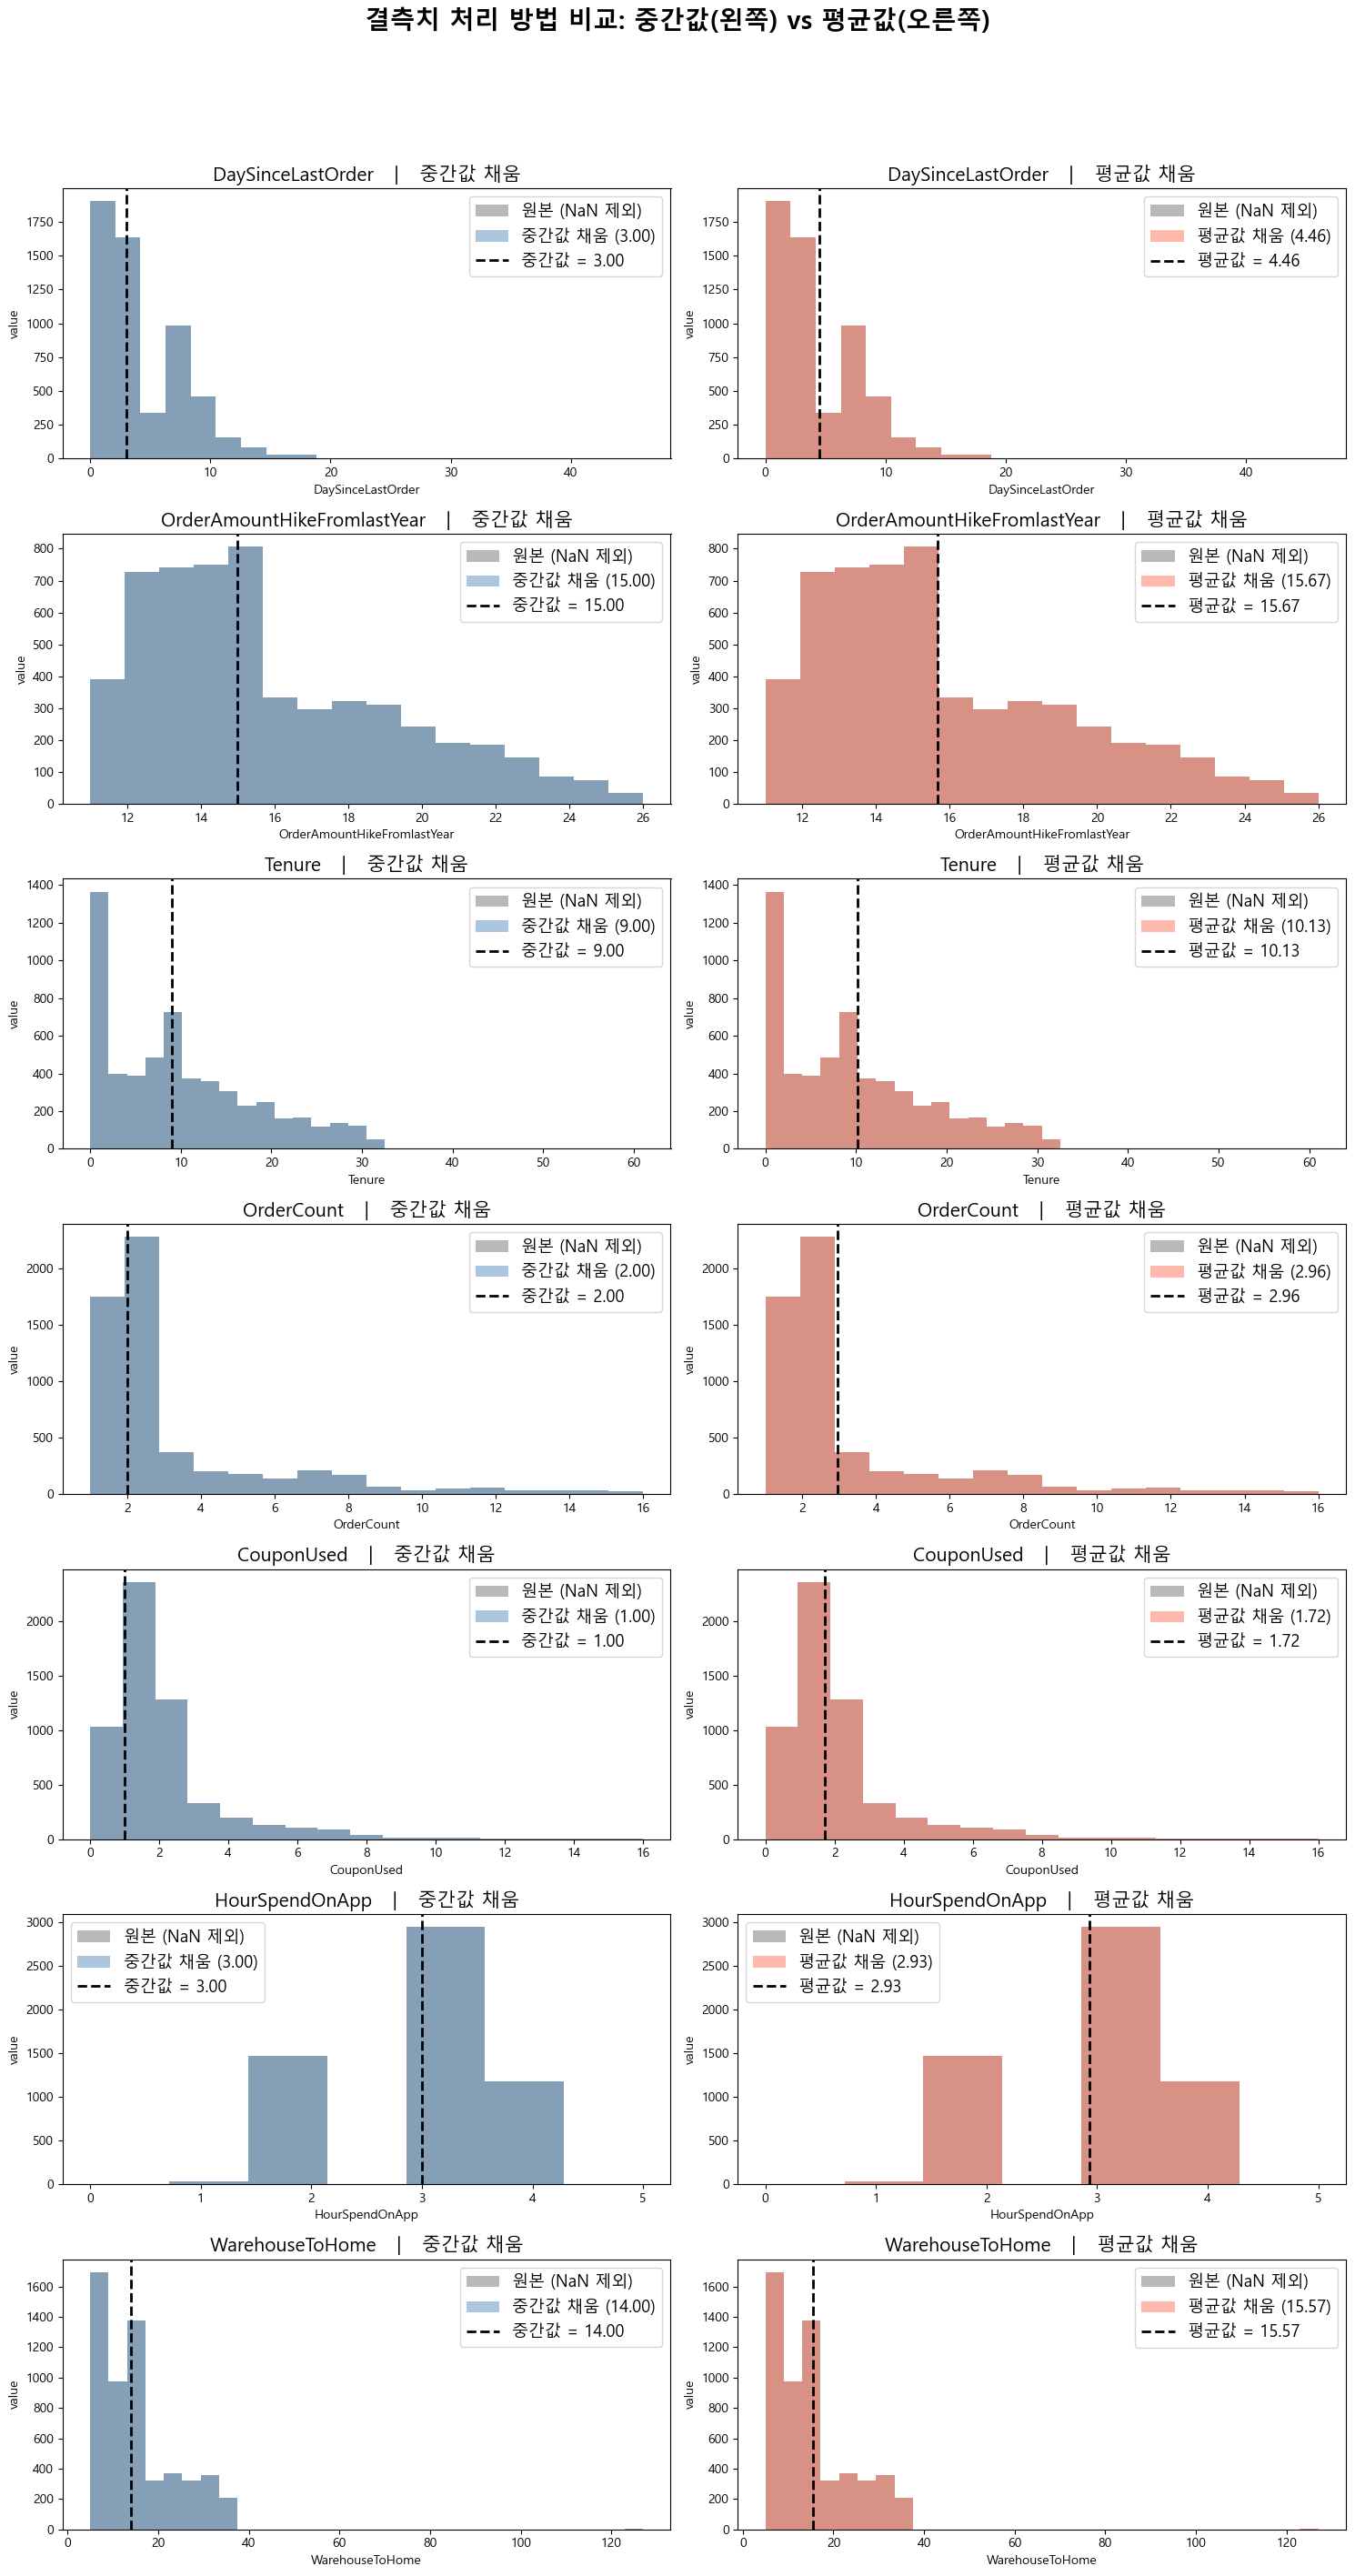

,결측치 수,중간값,평균값,왜도(skewness),권장
DaySinceLastOrder,0,3.000000,4.460000,1.270000,중간값 권장 (|왜도|>0.5)
OrderAmountHikeFromlastYear,0,15.000000,15.670000,0.840000,중간값 권장 (|왜도|>0.5)
Tenure,0,9.000000,10.130000,0.770000,중간값 권장 (|왜도|>0.5)
OrderCount,0,2.000000,2.960000,2.280000,중간값 권장 (|왜도|>0.5)
CouponUsed,0,1.000000,1.720000,2.630000,중간값 권장 (|왜도|>0.5)
HourSpendOnApp,0,3.000000,2.930000,-0.030000,평균값 권장
WarehouseToHome,0,14.000000,15.570000,1.680000,중간값 권장 (|왜도|>0.5)


In [35]:
# ─────────────────────────────────────────────
# 2. 결측치 방법 비교 (중간값 vs 평균)
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# 결측치가 있는 컬럼 목록
missing_cols = [
    "DaySinceLastOrder",
    "OrderAmountHikeFromlastYear",
    "Tenure",
    "OrderCount",
    "CouponUsed",
    "HourSpendOnApp",
    "WarehouseToHome"
]

n = len(missing_cols)
fig, axes = plt.subplots(n, 2, figsize=(15, 4 * n))
fig.suptitle("결측치 처리 방법 비교: 중간값(왼쪽) vs 평균값(오른쪽)", fontsize=20, fontweight="bold", y=1.01)

for i, col in enumerate(missing_cols):
    original   = df[col].dropna()
    median_val = df[col].median()
    mean_val   = df[col].mean()

    filled_median = df[col].fillna(median_val)
    filled_mean   = df[col].fillna(mean_val)

    bins = min(30, int(df[col].nunique()))
    bin_edges_m = np.histogram_bin_edges(filled_median, bins=bins)
    bin_edges_n = np.histogram_bin_edges(filled_mean,   bins=bins)

    # ── 왼쪽: 중간값 채움 ──
    ax_l = axes[i, 0]
    ax_l.hist(original,      bins=bin_edges_m, alpha=0.55, color="gray",     label="원본 (NaN 제외)")
    ax_l.hist(filled_median, bins=bin_edges_m, alpha=0.45, color="steelblue", label=f"중간값 채움 ({median_val:.2f})")
    ax_l.axvline(median_val, color="black", linestyle="--", linewidth=2, label=f"중간값 = {median_val:.2f}")
    ax_l.set_title(f"{col}  ┃  중간값 채움", fontsize=15)
    ax_l.set_xlabel(col)
    ax_l.set_ylabel("value")
    ax_l.legend(fontsize=13)

    # ── 오른쪽: 평균값 채움 ──
    ax_r = axes[i, 1]
    ax_r.hist(original,    bins=bin_edges_n, alpha=0.55, color="gray",   label="원본 (NaN 제외)")
    ax_r.hist(filled_mean, bins=bin_edges_n, alpha=0.45, color="tomato", label=f"평균값 채움 ({mean_val:.2f})")
    ax_r.axvline(mean_val, color="black", linestyle="--", linewidth=2, label=f"평균값 = {mean_val:.2f}")
    ax_r.set_title(f"{col}  ┃  평균값 채움", fontsize=15)
    ax_r.set_xlabel(col)
    ax_r.set_ylabel("value")
    ax_r.legend(fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# 요약 테이블 출력
summary = pd.DataFrame({
    "결측치 수": df[missing_cols].isnull().sum(),
    "중간값": df[missing_cols].median().round(2),
    "평균값": df[missing_cols].mean().round(2),
    "왜도(skewness)": df[missing_cols].skew().round(2)
})
summary["권장"] = summary["왜도(skewness)"].apply(
    lambda s: "중간값 권장 (|왜도|>0.5)" if abs(s) > 0.5 else "평균값 권장"
)

# 많이 치우쳐진 CouponUsed, OrderCount는 결측치 처리 후, 로그 변환 예정

display(summary.style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

### 3. 결측치 처리

- DaySinceLastOrder             : 중간값(median)적용
- OrderAmountHikeFromlastYear   : 중간값(median)적용
- Tenure                        : 중간값(median)적용
- OrderCount                    : 중간값(median)적용
- CouponUsed                    : 중간값(median)적용
- HourSpendOnApp                : 평균값(mean)적용
- WarehouseToHome               : 중간값(median)적용

In [ ]:
# ─────────────────────────────────────────────
# 3. 결측치 채우기
# ─────────────────────────────────────────────
# 결측치 채우기 전 원본 보관
df_before = df.copy()
print('원본 저장 완료 (df_before)')

fill_method = "median"   

for col in missing_cols:
    if col == "HourSpendOnApp":
        # HourSpendOnApp은 설정과 상관없이 무조건 평균값 적용
        df[col] = df[col].fillna(df[col].mean())
        print(f"- {col:30s}: 평균값(mean)적용")
    else:
        # 나머지 컬럼은 기본 설정된 방법(median) 적용
        if fill_method == "median":
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())
        print(f"- {col:30s}: 중간값(median)적용")

remaining = df[missing_cols].isnull().sum().sum()
print(f"\n✅ 결측치 채움 완료")
print(f"   남은 결측치: {remaining}개")

원본 저장 완료 (df_before)
- DaySinceLastOrder             : 중간값(median)적용
- OrderAmountHikeFromlastYear   : 중간값(median)적용
- Tenure                        : 중간값(median)적용
- OrderCount                    : 중간값(median)적용
- CouponUsed                    : 중간값(median)적용
- HourSpendOnApp                : 평균값(mean)적용
- WarehouseToHome               : 중간값(median)적용

✅ 결측치 채움 완료
   남은 결측치: 0개


In [55]:

# 결측치가 있던 행들 5개 추출
null_mask = df_before[missing_cols].isnull().any(axis=1)
null_idx  = df_before[null_mask].index[:5]

print('=== 🔈처리 전 (NaN 있는 상태) ===')
display(df_before.loc[null_idx].style
        .format(subset=df_before
        .select_dtypes(include='number').columns, formatter="{:.2f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

print('\n=== 🔊 처리 후 (채워진 상태) ===')
num_cols = df.select_dtypes(include='number').columns
display(df.loc[null_idx].style
        .format(subset=[col for col in num_cols if col in df.columns], formatter="{:.2f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

=== 🔈처리 전 (NaN 있는 상태) ===


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1,50002.00,1.00,nan,Phone,1.00,8.00,UPI,Male,3.00,4.00,Mobile,3.00,Single,7.00,1.00,15.00,0.00,1.00,0.00,121.00
2,50003.00,1.00,nan,Phone,1.00,30.00,Debit Card,Male,2.00,4.00,Mobile,3.00,Single,6.00,1.00,14.00,0.00,1.00,3.00,120.00
4,50005.00,1.00,0.00,Phone,1.00,12.00,Credit Card,Male,nan,3.00,Mobile,5.00,Single,3.00,0.00,11.00,1.00,1.00,3.00,130.00
6,50007.00,1.00,nan,Phone,3.00,11.00,COD,Male,2.00,3.00,Laptop & Accessory,2.00,Divorced,4.00,0.00,14.00,0.00,1.00,0.00,121.00
7,50008.00,1.00,nan,Phone,1.00,6.00,Credit Card,Male,3.00,3.00,Mobile,2.00,Divorced,3.00,1.00,16.00,2.00,2.00,0.00,123.00



=== 🔊 처리 후 (채워진 상태) ===


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderCount_log,CouponUsed_log
1,50002.00,1.00,9.00,Phone,1.00,8.00,UPI,Male,3.00,4.00,Mobile,3.00,Single,7.00,1.00,15.00,0.00,1.00,0.00,121.00,0.69,0.00
2,50003.00,1.00,9.00,Phone,1.00,30.00,Debit Card,Male,2.00,4.00,Mobile,3.00,Single,6.00,1.00,14.00,0.00,1.00,3.00,120.00,0.69,0.00
4,50005.00,1.00,0.00,Phone,1.00,12.00,Credit Card,Male,2.93,3.00,Mobile,5.00,Single,3.00,0.00,11.00,1.00,1.00,3.00,130.00,0.69,0.69
6,50007.00,1.00,9.00,Phone,3.00,11.00,COD,Male,2.00,3.00,Laptop & Accessory,2.00,Divorced,4.00,0.00,14.00,0.00,1.00,0.00,121.00,0.69,0.00
7,50008.00,1.00,9.00,Phone,1.00,6.00,Credit Card,Male,3.00,3.00,Mobile,2.00,Divorced,3.00,1.00,16.00,2.00,2.00,0.00,123.00,1.10,1.10


,처리 전,처리 후,채워진 수
CouponUsed,256,0,256
DaySinceLastOrder,307,0,307
HourSpendOnApp,255,0,255
OrderAmountHikeFromlastYear,265,0,265
OrderCount,258,0,258
Tenure,264,0,264
WarehouseToHome,251,0,251


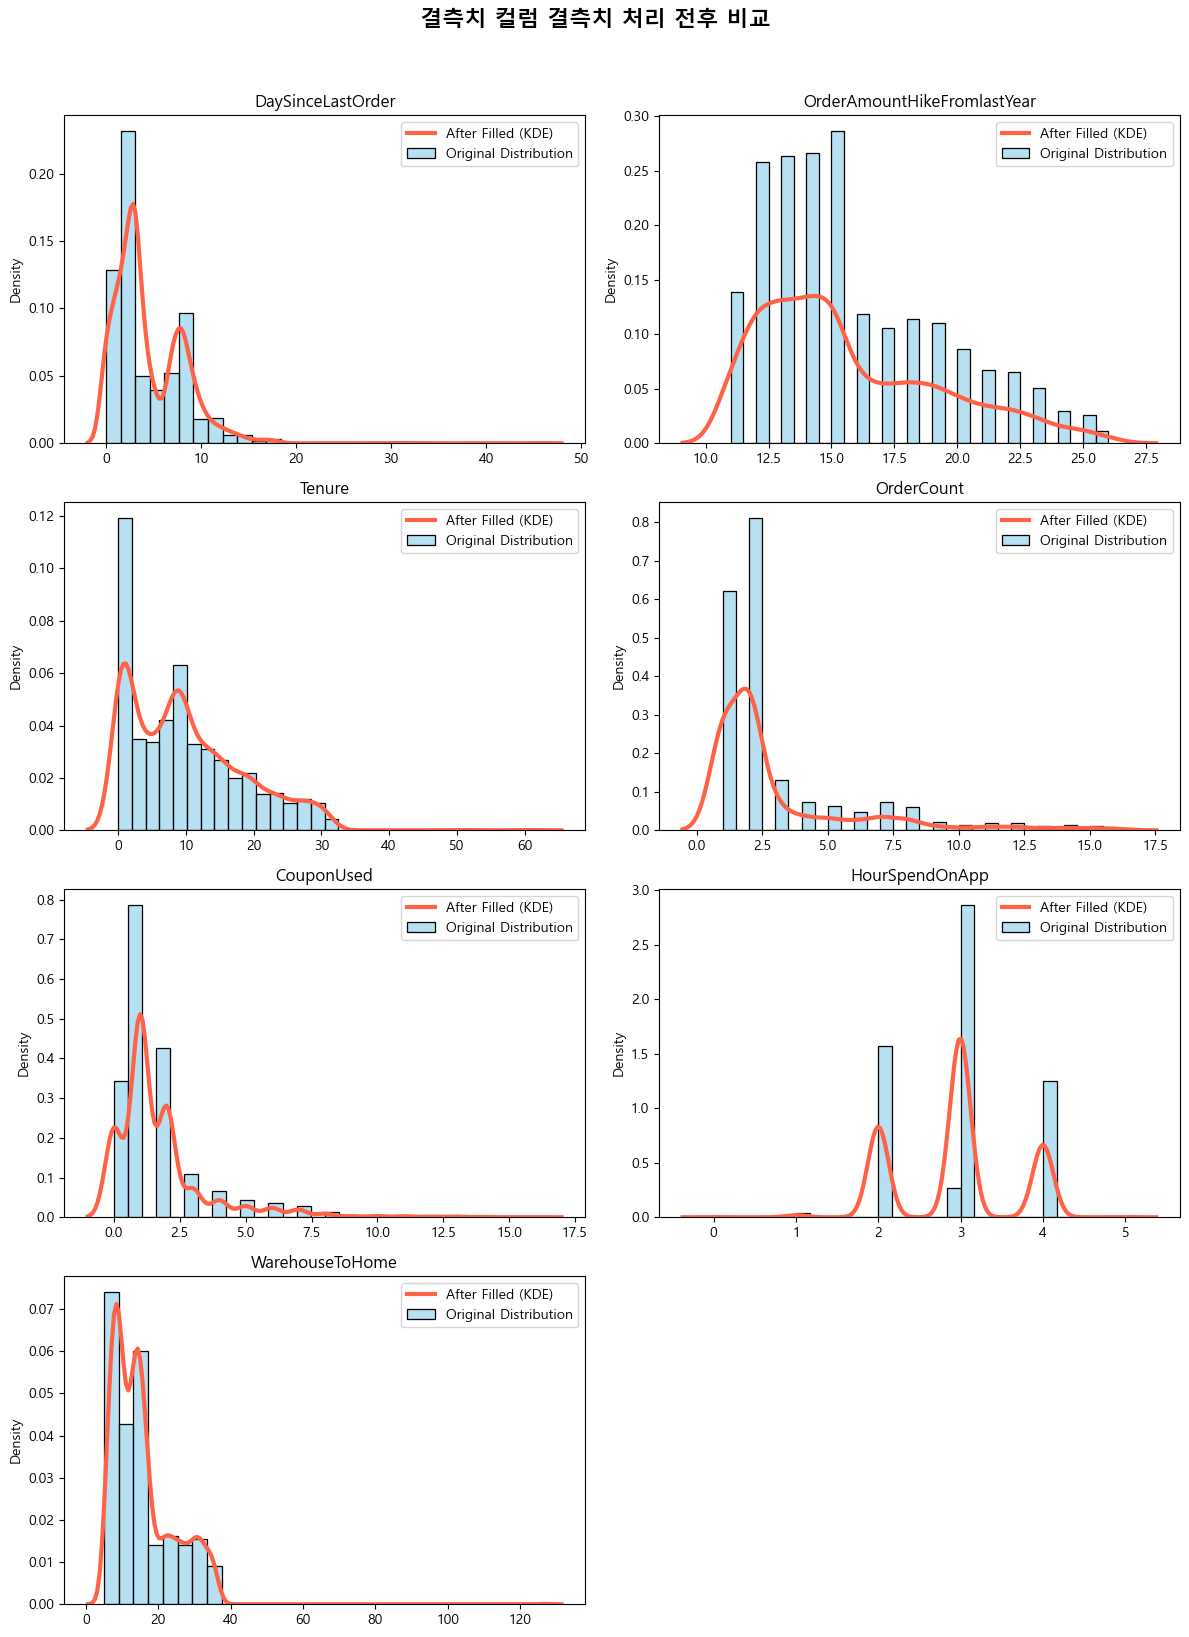

In [14]:
# ─────────────────────────────────────────────
# 4. 결측치 전, 후 비교
# ─────────────────────────────────────────────
after_sr = df[missing_cols].isnull().sum()

compare = pd.DataFrame({
    "처리 전": missing_sr,
    "처리 후": after_sr,
    "채워진 수": missing_sr - after_sr,
})
display(compare.style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# ─────────────────────────────────────────────
# 5. 시각화
# ─────────────────────────────────────────────
all_missing_cols = missing_cols

n_cols = 2
n_rows = (len(all_missing_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("결측치 컬럼 결측치 처리 전후 비교", fontsize=16, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(all_missing_cols):
    # Before: 원본 데이터 (막대)
    sns.histplot(df[col], bins=30, kde=False, ax=axes[i], 
                 color='skyblue', label='Original Distribution', stat="density", alpha=0.6)
    
    # After: 결측치 처리 후 분포 (선)
    sns.kdeplot(df[col], ax=axes[i], color='tomato', 
                linewidth=3, label='After Filled (KDE)')
    
    axes[i].set_title(f"{col}")
    axes[i].legend(loc='upper right')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# 데이터 개수가 홀수일 경우 남는 빈 칸 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3. 이상치

- 이상치 분포 왜곡 `CouponUsed`,`OrderCount`,`NumberOfDeviceRegistered` 
- `CouponUsed`,`OrderCount`는 숫자 범위가 매우 큼 -> 로그변환 
- `NumberOfDeviceRegistered`는 값의 범위가 좁고 딱딱 끊어지는 숫자 -> 기존 유지

In [15]:
# 이상치 탐색
exclude = {'Churn', 'CustomerID'}
num_cols = [col for col in df.select_dtypes(include='number').columns if col not in exclude]
overall_churn = df["Churn"].mean()

outlier_info = {}   # 시각화에서 col 키로 접근
outlier_list = []   # 요약 테이블용
rows = []           # 판단 테이블용

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    mask   = (df[col] < lower) | (df[col] > upper)
    n_out  = int(mask.sum())
    out_churn  = df.loc[mask,  "Churn"].mean() if n_out > 0 else 0.0
    norm_churn = df.loc[~mask, "Churn"].mean()
    diff       = out_churn - norm_churn

    outlier_info[col] = dict(
        lower=lower, upper=upper,
        n_out=n_out, pct=round(n_out / len(df) * 100, 2),
        out_churn=out_churn, norm_churn=norm_churn, diff=diff,
        mask=mask
    )

    outlier_list.append({
        '컬럼명'          : col,
        '이상치 수'        : n_out,
        '비율(%)'         : f"{n_out / len(df) * 100:.2f}%",
        '정상 하한(Lower)' : round(lower, 2),
        '정상 상한(Upper)' : round(upper, 2),
        '최솟값'           : df[col].min(),
        '최댓값'           : df[col].max()
    })

    if abs(diff) > 0.05:
        tag = "★ 정보성 (유지 권장)"
    elif n_out > 200:
        tag = "▲ 분포왜곡 (변환 권장)"
    else:
        tag = "○ 소량/무관"

    rows.append({
        '컬럼명'     : col,
        '이상치 이탈률': round(out_churn, 4),
        '정상 이탈률' : round(norm_churn, 4),
        '차이'       : round(diff, 4),
        '판단'       : tag
    })

# 피처-Churn 상관계수 (이후 시각화에서 사용)
corr_vals = df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn")

# 이상치 수 기준 요약 테이블
df_outlier_summary = pd.DataFrame(outlier_list).sort_values(by='이상치 수', ascending=False)
print("📊 수치형 변수 이상치 탐색 결과 요약")                # 표안에 문자열(string)이 일을 때 소수점
display(df_outlier_summary.reset_index(drop=True).style.format(subset=df_outlier_summary.select_dtypes(include='number').columns, formatter="{:.2f}")
                .set_properties(**{'text-align': 'left'})
                .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# 이탈률 판단 테이블
df_outlier_judge = pd.DataFrame(rows).sort_values(by='차이', key=abs, ascending=False)
print("📋 이상치 이탈률 판단")
display(df_outlier_judge.reset_index(drop=True).style.format(subset=df_outlier_judge.select_dtypes(include='number').columns, formatter="{:.2f}")
                .set_properties(**{'text-align': 'left'})
                .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))


📊 수치형 변수 이상치 탐색 결과 요약


,컬럼명,이상치 수,비율(%),정상 하한(Lower),정상 상한(Upper),최솟값,최댓값
0,OrderCount,703.00,12.49%,-2.00,6.00,1.00,16.00
1,CouponUsed,629.00,11.17%,-0.50,3.50,0.00,16.00
2,CashbackAmount,447.00,7.94%,71.00,271.00,0.00,325.00
3,NumberOfDeviceRegistered,397.00,7.05%,1.50,5.50,1.00,6.00
4,DaySinceLastOrder,62.00,1.10%,-5.50,14.50,0.00,46.00
5,OrderAmountHikeFromlastYear,33.00,0.59%,5.50,25.50,11.00,26.00
6,HourSpendOnApp,6.00,0.11%,0.50,4.50,0.00,5.00
7,Tenure,4.00,0.07%,-15.00,33.00,0.00,61.00
8,NumberOfAddress,4.00,0.07%,-4.00,12.00,1.00,22.00
9,WarehouseToHome,2.00,0.04%,-7.50,36.50,5.00,127.00


📋 이상치 이탈률 판단


,컬럼명,이상치 이탈률,정상 이탈률,차이,판단
0,NumberOfAddress,0.50,0.17,0.33,★ 정보성 (유지 권장)
1,HourSpendOnApp,0.00,0.17,-0.17,★ 정보성 (유지 권장)
2,Tenure,0.00,0.17,-0.17,★ 정보성 (유지 권장)
3,CityTier,0.00,0.17,-0.17,★ 정보성 (유지 권장)
4,WarehouseToHome,0.00,0.17,-0.17,★ 정보성 (유지 권장)
5,SatisfactionScore,0.00,0.17,-0.17,★ 정보성 (유지 권장)
6,Complain,0.00,0.17,-0.17,★ 정보성 (유지 권장)
7,CashbackAmount,0.04,0.18,-0.13,★ 정보성 (유지 권장)
8,OrderAmountHikeFromlastYear,0.06,0.17,-0.11,★ 정보성 (유지 권장)
9,DaySinceLastOrder,0.08,0.17,-0.09,★ 정보성 (유지 권장)


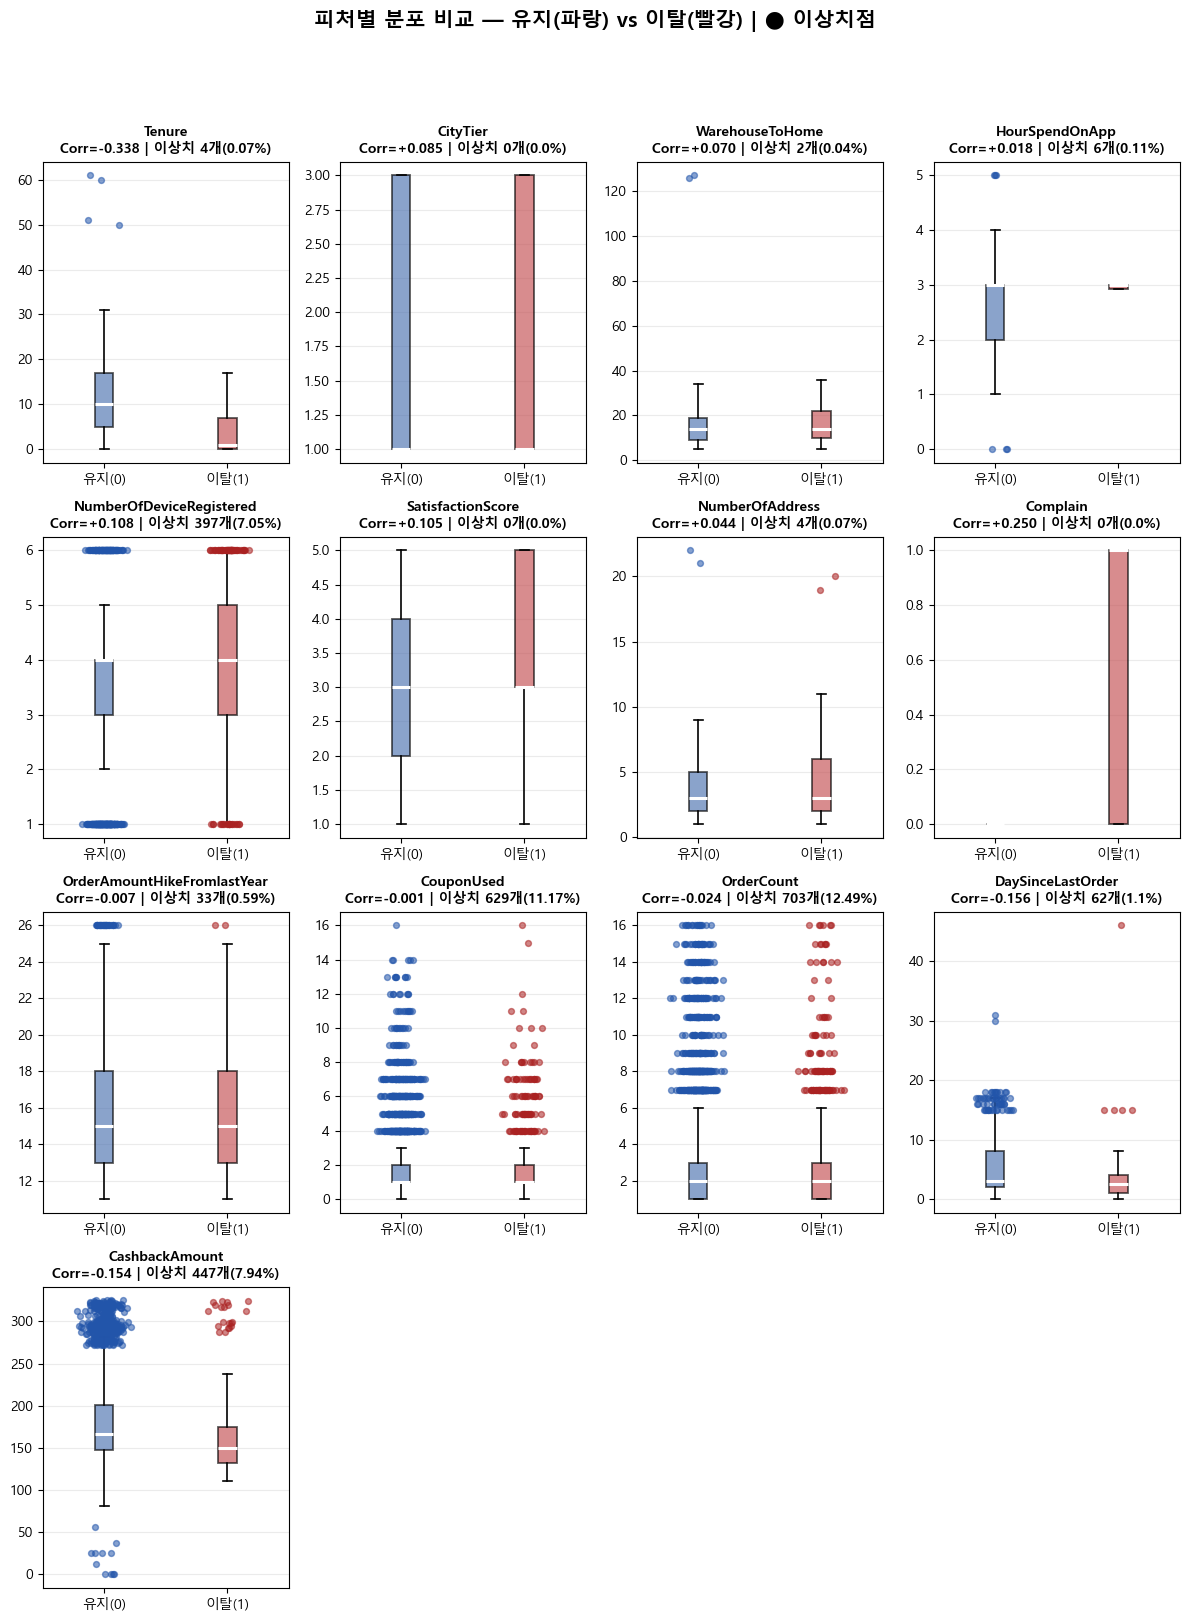

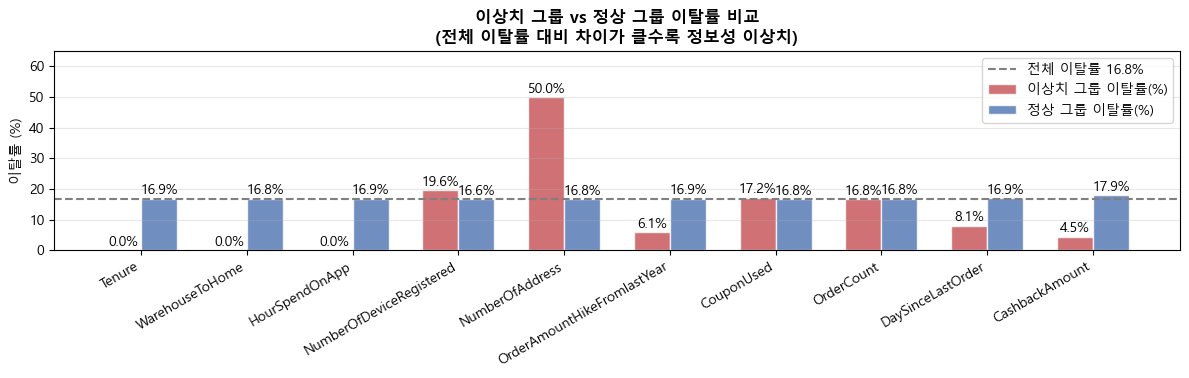

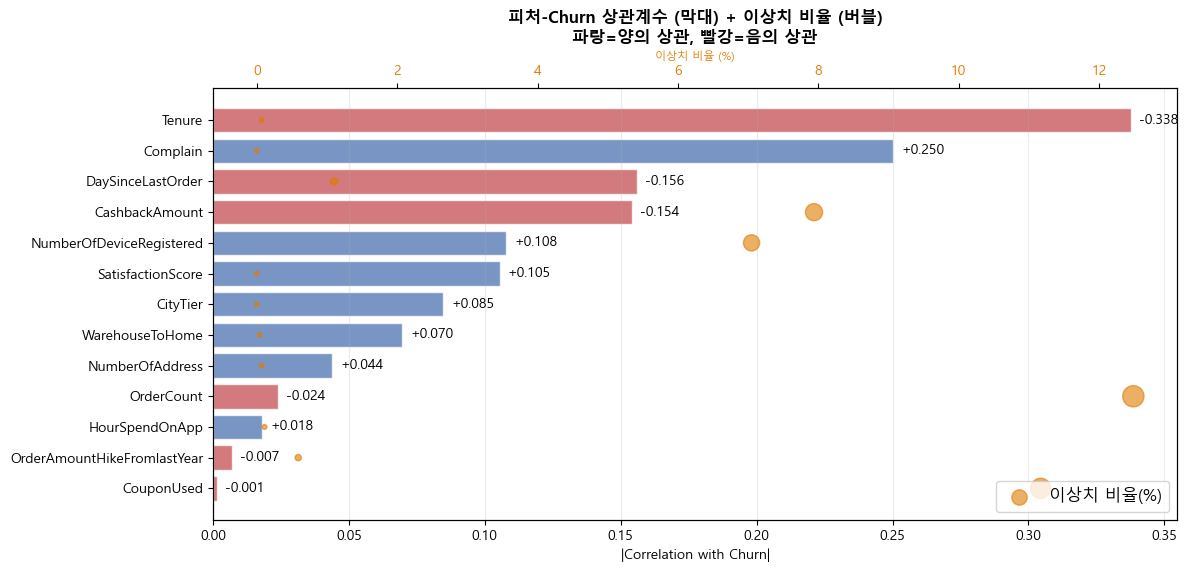

In [16]:
# 시각화
# ════════════════════════════════════════════════════════════════════
# 【Fig 1】 Churn별 피처 분포 비교 (이탈=빨강 / 유지=파랑)
# ════════════════════════════════════════════════════════════════════
N_COLS = 4
N_ROWS = -(-len(num_cols) // N_COLS)  # ceiling division
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, N_ROWS * 4))
fig.suptitle("피처별 분포 비교 — 유지(파랑) vs 이탈(빨강) | ● 이상치점",
             fontsize=15, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax   = axes_flat[i]
    info = outlier_info[col]
    g0 = df[df["Churn"]==0][col]
    g1 = df[df["Churn"]==1][col]

    bp = ax.boxplot([g0, g1], patch_artist=True, labels=["유지(0)","이탈(1)"],
                    showfliers=False,
                    boxprops=dict(linewidth=1.3),
                    medianprops=dict(linewidth=2.2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    bp["boxes"][0].set_facecolor("#4C72B0"); bp["boxes"][0].set_alpha(0.65)
    bp["boxes"][1].set_facecolor("#C44E52"); bp["boxes"][1].set_alpha(0.65)
    bp["medians"][0].set_color("white")
    bp["medians"][1].set_color("white")

    # 이상치 점 overlay (원본 IQR 경계 기준)
    for j, (gdata, color) in enumerate([(g0,"#2255AA"),(g1,"#AA2222")], start=1):
        mask_g = (gdata < info["lower"]) | (gdata > info["upper"])
        outs   = gdata[mask_g]
        ax.scatter(np.random.normal(j, 0.07, size=len(outs)), outs,
                   color=color, s=18, alpha=0.55, zorder=4)

    corr_v = corr_vals[col]
    ax.set_title(f"{col}\nCorr={corr_v:+.3f} | 이상치 {info['n_out']}개({info['pct']}%)",
                 fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ════════════════════════════════════════════════════════════════════
# 【Fig 2】 이상치 이탈률 vs 정상 이탈률 비교 바 차트
# ════════════════════════════════════════════════════════════════════
# 이상치 있는 컬럼만 추출
has_out = [(col, outlier_info[col]) for col in num_cols if outlier_info[col]["n_out"] > 0]
labels  = [c for c,_ in has_out]
out_rates  = [v["out_churn"]*100 for _,v in has_out]
norm_rates = [v["norm_churn"]*100 for _,v in has_out]

x     = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 4))
b1 = ax.bar(x - width/2, out_rates,  width, label="이상치 그룹 이탈률(%)", color="#C44E52", alpha=0.8, edgecolor="white")
b2 = ax.bar(x + width/2, norm_rates, width, label="정상 그룹 이탈률(%)",   color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axhline(overall_churn*100, color="gray", linestyle="--", linewidth=1.5,
           label=f"전체 이탈률 {overall_churn*100:.1f}%")

for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("이탈률 (%)"); ax.set_ylim(0, 65)
ax.set_title("이상치 그룹 vs 정상 그룹 이탈률 비교\n(전체 이탈률 대비 차이가 클수록 정보성 이상치)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ════════════════════════════════════════════════════════════════════
# 【Fig 3】 피처-Churn 상관계수 + 이상치 비율 (버블 차트)
# ════════════════════════════════════════════════════════════════════
corr_sorted = corr_vals.abs().sort_values(ascending=True)
pct_vals    = [outlier_info[col]["pct"] for col in corr_sorted.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ["#C44E52" if corr_vals[c] < 0 else "#4C72B0" for c in corr_sorted.index]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors_bar, alpha=0.75, edgecolor="white")

# 이상치 비율 버블 overlay
ax2 = ax.twiny()
ax2.scatter(pct_vals, range(len(corr_sorted)),
            s=[p*18+10 for p in pct_vals], color="#E07B00", alpha=0.6,
            label="이상치 비율(%)", zorder=5)
ax2.set_xlabel("이상치 비율 (%)", color="#E07B00", fontsize=8)
ax2.tick_params(axis="x", labelcolor="#E07B00")
ax2.legend(loc="lower right", fontsize=12)

for bar, val, col in zip(bars, corr_sorted.values, corr_sorted.index):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f"{corr_vals[col]:+.3f}", va="center", fontsize=10)

ax.set_xlabel("|Correlation with Churn|", fontsize=10)
ax.set_title("피처-Churn 상관계수 (막대) + 이상치 비율 (버블)\n파랑=양의 상관, 빨강=음의 상관",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# 데이터 변환 및 피처 엔지니어링

#### 1. 이상치 처리 -> 로그변환

In [17]:
# ─────────────────────────────────────────────
#  1. OrderCount와 CouponUsed는 로그변환(왜도 완화)
# ─────────────────────────────────────────────
df['OrderCount_log'] = np.log1p(df['OrderCount'])
df['CouponUsed_log'] = np.log1p(df['CouponUsed'])

# 기존 OrderCount, CouponUsed 삭제해서(로그변환하니) df_encoded 생성
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['OrderCount', 'CouponUsed'], errors='ignore')

# 로그변환한 것 -> df_encoded 담음 (df 복사본, 컬럼 수 동일)
df_encoded.describe().T.style.format("{:.2f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
                        

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.00,52815.50,1625.39,50001.00,51408.25,52815.50,54222.75,55630.00
Churn,5630.00,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,5630.00,10.13,8.36,0.00,3.00,9.00,15.00,61.00
CityTier,5630.00,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,5630.00,15.57,8.35,5.00,9.00,14.00,20.00,127.00
HourSpendOnApp,5630.00,2.93,0.71,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.00,3.69,1.02,1.00,3.00,4.00,4.00,6.00
SatisfactionScore,5630.00,3.07,1.38,1.00,2.00,3.00,4.00,5.00
NumberOfAddress,5630.00,4.21,2.58,1.00,2.00,3.00,6.00,22.00
Complain,5630.00,0.28,0.45,0.00,0.00,0.00,1.00,1.00


#### 2. 라벨 인코딩(범주형 -> 수치화)

In [18]:
# 범주형 -> 수치화
cat_cols = [
    "PreferredLoginDevice",  # Computer / Phone
    "PreferredPaymentMode",  # Cash on Delivery / Credit Card / Debit Card / E wallet / UPI
    "Gender",                # Female / Male
    "PreferedOrderCat",      # Fashion / Grocery / Laptop & Accessory / Mobile / Others
    "MaritalStatus",         # Divorced / Married / Single
]

# Before: 원본 데이터 (범주형 포함, df 보존) 
print("🔈Before — 원본 데이터 (범주형 포함, df 유지)")

display(df[cat_cols].head(5).style.set_properties(**{'text-align': 'left'})
                    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
print(f"원본 전체 컬럼 수: {df.shape[1]}개  |  데이터 크기: {df.shape}")


# Label Encoding 
label_encoders = {}
encoding_map   = {}

for col in cat_cols:
    le = LabelEncoder()
    # 결측치가 섞여있을 수 있으므로 astype(str)로 변환 후 인코딩하는 것은 아주 좋은 선택입니다.
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    encoding_map[col]   = dict(zip(le.classes_, le.transform(le.classes_).tolist()))


# After: 수치형 변환 데이터
print("\n" + "=" * 65)
print("🔊After  — 수치형 변환 데이터 (df_encoded, 컬럼 수 동일)")

display(df_encoded[cat_cols].head(5).style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
print(f"컬럼 수: {df_encoded.shape[1]}개  |  데이터 크기: {df_encoded.shape}")

print()
print("📋 인코딩 매핑:")
for col, mapping in encoding_map.items():
    print(f"  {col:23s}: {mapping}")

🔈Before — 원본 데이터 (범주형 포함, df 유지)


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Phone,Debit Card,Female,Laptop & Accessory,Single
1,Phone,UPI,Male,Mobile,Single
2,Phone,Debit Card,Male,Mobile,Single
3,Phone,Debit Card,Male,Laptop & Accessory,Single
4,Phone,Credit Card,Male,Mobile,Single


원본 전체 컬럼 수: 22개  |  데이터 크기: (5630, 22)

🔊After  — 수치형 변환 데이터 (df_encoded, 컬럼 수 동일)


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,1,2,0,2,2
1,1,4,1,3,2
2,1,2,1,3,2
3,1,2,1,2,2
4,1,1,1,3,2


컬럼 수: 20개  |  데이터 크기: (5630, 20)

📋 인코딩 매핑:
  PreferredLoginDevice   : {'Computer': 0, 'Phone': 1}
  PreferredPaymentMode   : {'COD': 0, 'Credit Card': 1, 'Debit Card': 2, 'E wallet': 3, 'UPI': 4}
  Gender                 : {'Female': 0, 'Male': 1}
  PreferedOrderCat       : {'Fashion': 0, 'Grocery': 1, 'Laptop & Accessory': 2, 'Mobile': 3, 'Others': 4}
  MaritalStatus          : {'Divorced': 0, 'Married': 1, 'Single': 2}


In [19]:
# df_encoded 확인               # 소수점 자리      #왼쪽 정렬
df_encoded.describe().T.style.format("{:.2f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.00,52815.50,1625.39,50001.00,51408.25,52815.50,54222.75,55630.00
Churn,5630.00,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,5630.00,10.13,8.36,0.00,3.00,9.00,15.00,61.00
PreferredLoginDevice,5630.00,0.71,0.45,0.00,0.00,1.00,1.00,1.00
CityTier,5630.00,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,5630.00,15.57,8.35,5.00,9.00,14.00,20.00,127.00
PreferredPaymentMode,5630.00,1.76,1.01,0.00,1.00,2.00,2.00,4.00
Gender,5630.00,0.60,0.49,0.00,0.00,1.00,1.00,1.00
HourSpendOnApp,5630.00,2.93,0.71,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.00,3.69,1.02,1.00,3.00,4.00,4.00,6.00


#### 3. 스케일링

In [20]:
# 스케일링 대상 컬럼 (X_train 기준으로 선택)
scale_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

# X_train으로만 fit → val/test는 transform만 (data leakage 방지)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[scale_cols])
X_val_scaled   = scaler.transform(X_val[scale_cols])
X_test_scaled  = scaler.transform(X_test[scale_cols])

print("✅ 스케일링 완료 (X_train_scaled 기준 fit, leakage 없음)")
print(f"   스케일링 컬럼 수: {len(scale_cols)}개")
display(X_train[scale_cols].describe().T.round(4).style.format("{:.3f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

✅ 스케일링 완료 (X_train_scaled 기준 fit, leakage 없음)
   스케일링 컬럼 수: 13개


,count,mean,std,min,25%,50%,75%,max
Tenure,3228.000,10.149,8.525,0.000,2.000,9.000,16.000,61.000
CityTier,3378.000,1.670,0.920,1.000,1.000,1.000,3.000,3.000
WarehouseToHome,3219.000,15.656,8.475,5.000,9.000,14.000,20.000,127.000
HourSpendOnApp,3233.000,2.933,0.722,1.000,2.000,3.000,3.000,5.000
NumberOfDeviceRegistered,3378.000,3.693,1.029,1.000,3.000,4.000,4.000,6.000
SatisfactionScore,3378.000,3.050,1.392,1.000,2.000,3.000,4.000,5.000
NumberOfAddress,3378.000,4.244,2.589,1.000,2.000,3.000,6.000,22.000
Complain,3378.000,0.284,0.451,0.000,0.000,0.000,1.000,1.000
OrderAmountHikeFromlastYear,3227.000,15.646,3.621,11.000,13.000,15.000,18.000,26.000
CouponUsed,3215.000,1.773,1.924,0.000,1.000,1.000,2.000,16.000


In [21]:
# OrderCount_log, CouponUsed_log 스케일링

eda_scale_cols = ["OrderCount_log", "CouponUsed_log"]
eda_scaler = StandardScaler()

df_encoded_scaled = df_encoded.copy()
df_encoded_scaled[eda_scale_cols] = eda_scaler.fit_transform(df_encoded[eda_scale_cols])

display(df_encoded_scaled[eda_scale_cols].describe().T.round(4).style.format("{:.3f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,count,mean,std,min,25%,50%,75%,max
OrderCount_log,5630.000,0.000,1.000,-0.965,-0.965,-0.202,0.340,3.063
CouponUsed_log,5630.000,0.000,1.000,-1.510,-0.255,-0.255,0.479,3.621


In [22]:
print(X_train_scaled.info())

AttributeError: 'numpy.ndarray' object has no attribute 'info'

# 상관관계 분석
### 1. 변수 간 상관관계 분석
**분석 목적:**
- 고객 이탈(Churn)과 각 변수 간의 상관관계를 파악
- 변수들 간의 다중공선성(Multicollinearity) 문제 탐지
- 상관관계가 높은 변수들을 그룹으로 묶어 해석

#### 1. 상관관계 히트맵 : 피처 간 상관관계 + Churn과의 상관관계

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 1 — 상관관계 히트맵】 피처 간 상관관계 + Churn과의 상관관계
# ════════════════════════════════════════════════════════════════════

train_analysis = X_train_scaled.copy()
train_analysis['Churn'] = y_train.values

# 분석 대상: CustomerID 제외, 전체 수치형 변수
analysis_cols = train_analysis.columns.tolist()
corr_matrix = train_analysis.corr()

# 전체 상관관계 히트맵 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))

# 상관계수 히트맵 그리기
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 상삼각 mask (선택사항)
cmap = plt.cm.RdBu_r  # 빨강=양의 상관, 파랑=음의 상관

im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# 컬러바
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("상관계수", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# 축 설정
ax.set_xticks(range(len(analysis_cols)))
ax.set_yticks(range(len(analysis_cols)))
ax.set_xticklabels(analysis_cols, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(analysis_cols, fontsize=12)

# 상관계수 값 텍스트 추가
for i in range(len(analysis_cols)):
    for j in range(len(analysis_cols)):
        val = corr_matrix.values[i, j]
        if i != j:  # 대각선 제외 (대각선은 항상 1)
            # 배경색에 따라 글자색 변경
            text_color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                   fontsize=13, color=text_color, fontweight="bold")

ax.set_title("전체 변수 간 상관관계 히트맵\n(빨강=양의 상관, 파랑=음의 상관)", 
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

#### 2. Churn 상관관계 바 차트 : Churn과의 상관관계 정렬

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 2 — Churn 상관관계 바 차트】 Churn과의 상관관계 정렬
# ════════════════════════════════════════════════════════════════════
train_analysis = X_train_scaled.copy()
train_analysis['Churn'] = y_train.values
corr_matrix = train_analysis.corr()

# Churn과의 상관계수 추출 (기존 코드와 동일)
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

# 참조 영역 배경
ax.axvspan(0.1, 0.3, alpha=0.3, color="#ffd199", label="약한~중간 상관")
ax.axvspan(-0.3, -0.1, alpha=0.3, color="#ffd199")
ax.axvspan(0.3, 1.0, alpha=0.3, color="#bada55", label="중간~강한 상관")
ax.axvspan(-1.0, -0.3, alpha=0.3, color="#bada55")

# 색상 설정: 양의 상관(빨강) vs 음의 상관(파랑)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in churn_corr.values]

bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, alpha=0.8, edgecolor="white")

# 상관계수 값 텍스트
for bar, val in zip(bars, churn_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=14, fontweight="bold")

# 기준선
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(-0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

ax.set_xlabel("상관계수 (Pearson)", fontsize=14)
ax.set_title("변수별 Churn과의 상관관계\n(빨강=양의 상관→이탈 증가, 파랑=음의 상관→이탈 감소)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=14)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Churn 상관관계 요약:")
print(churn_corr.sort_values(ascending=False).round(3).to_string())

### 2. 변수 그룹핑 분석 (상관관계 기반)

**분석 목적:**
- <mark style='background-color: LemonChiffon'>데이터의 단순화</mark> : 18개의 변수를 일일이 대응하는 대신 컬럼별 상관관계 기반으로 그룹을 묶어 비즈니스 전략을 세우기 쉬운 지표로 변환
- <mark style='background-color: LemonChiffon'>복합적 요인 파악</mark> : 고객은 단 하나의 이유로 떠나지 않기에 여러 요인이 결합되었을 때, 발생하는 시너지 효과 확인
- <mark style='background-color: LemonChiffon'>전략적 우선순위 설정</mark> : 어떤 서비스 영역(프로모션, 품질, 프로필 등)을 가장 먼저 개선해야 이탈을 효율적으로 막을 수 있는지 결정

각 그룹의 변수들을 표준화 후 평균 → 그룹 합성 점수(1컬럼)로 만들어
각 그룹이 Churn과 얼마나 상관되는지 비교

**그룹핑 기준 및 결과 해석**

| 그룹명 | 포함 변수 | 논리적 연결고리 | 상관계수 | 해석 |
|---|---|---|---|---|
| **라이프스테이지 반응성** | Complain, MaritalStatus | 결혼 여부와 서비스 불만이 결합했을 때 나타나는 이탈 민감도와 생활 환경별 반응 차이 측정 | 0.257 | (최우선 관리 대상) 고객의 생활 환경과 불만이 결합될 때 이탈 위험이 가장 큼 |
| **프로모션 및 기대 관리** | Complain, SatisfactionScore, CouponUsed_log | 쿠폰 혜택(보상)과 주관적 만족 사이의 간극이 불만으로 터져 나오는 심리적 경로 분석 | 0.162 | 특정 인구통계학적 특성에 따라 이탈 경향이 다르게 나타나므로 타겟팅이 필요 |
| **고객 프로필** | Gender, MaritalStatus, SatisfactionScore | 결혼 여부나 성별 같은 요소가 만족도와 결합하여 특정 환경의 고객이 느끼는 고유한 불만 지점 및 가치 투영 방식 분석 | 0.143 | 쿠폰이나 만족도 관리가 이탈에 어느 정도 방어 역할 |
| **불만/품질** | Complain, OrderAmountHikeFromlastYear | 이용 의존도 증가와 서비스 품질 문제가 충돌할 때 발생하는 심리적 배신감 및 이탈 임계점 파악| 0.024 | 의외로 품질 지표 자체는 그룹 단위로 묶었을 때 영향력이 거의 없음 |'

#### 1. 그룹별 상관관계 히트맵 : 그룹핑된 변수들의 내부 상관관계

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 그룹 합성 점수 → Churn 상관관계
# 각 그룹의 변수들을 표준화 후 평균 → 그룹 합성 점수(1컬럼)로 만들어
# 각 그룹이 Churn과 얼마나 상관되는지 비교
# ════════════════════════════════════════════════════════════════════

var_groups = {
    "라이프스테이지 반응성\n(LifeStageResponse)": ["MaritalStatus", "Complain"],
    "프로모션 및 기대 관리\n(PromoExpectation)": ["CouponUsed_log", "SatisfactionScore", "Complain"],
    "고객 프로필\n(Profile)": ["Gender", "MaritalStatus", "SatisfactionScore"],
    "불만/품질\n(Complaint)": ["Complain", "OrderAmountHikeFromlastYear"],
}

# 그룹별 평균 컬럼을 담을 데이터프레임 생성
var_groups_score_df = pd.DataFrame()

for grp_name, cols in var_groups.items():
    clean_name = grp_name.replace("\n", " ")
    # 그룹 내 변수들의 평균을 계산하여 하나의 컬럼으로 생성
    var_groups_score_df[clean_name] = df_encoded_scaled[cols].mean(axis=1)

# Churn 추가 및 상관관계 계산
var_groups_score_df['Churn'] = df_encoded_scaled['Churn']
group_corr = var_groups_score_df.corr()['Churn'].drop('Churn').sort_values(ascending=True) # 아래에서 위로 그리기 위해 오름차순

# 시각화 (가로 막대 그래프)
plt.figure(figsize=(8, 4))

# 상관계수 값에 따라 색상 지정 (양수는 붉은 계열, 음수는 푸른 계열)
colors = ["#C44E52" if x > 0 else "#4C72B0" for x in group_corr.values]

bars = plt.barh(group_corr.index, group_corr.values, color=colors, height=0.6)

# 막대 끝에 수치 표시
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.005 if width >= 0 else width - 0.005
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
             f'{width:+.3f}', 
             va='center', 
             ha='left' if width >= 0 else 'right',
             fontsize=10, fontweight='bold')

plt.axvline(0, color='black', linewidth=0.8) # 기준선
plt.title('그룹별 합성 점수와 Churn의 상관관계', fontsize=12, pad=20)
plt.xlabel('Churn과의 상관계수')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

# 수치 결과 출력
print("📋 그룹별 Churn 상관관계 요약:")
df_group_corr = pd.DataFrame(group_corr.sort_values(ascending=False).round(3))
display(df_group_corr)

#### 2. Churn 상관관계 바 차트 : Churn과의 상관관계 정렬

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 2 — Churn 상관관계 바 차트】 Churn과의 상관관계 정렬
# ════════════════════════════════════════════════════════════════════

# Churn과의 상관계수 추출
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

# 참조 영역 배경
ax.axvspan(0.1, 0.3, alpha=0.3, color="#ffd199", label="약한~중간 상관")
ax.axvspan(-0.3, -0.1, alpha=0.3, color="#ffd199")
ax.axvspan(0.3, 1.0, alpha=0.3, color="#bada55", label="중간~강한 상관")
ax.axvspan(-1.0, -0.3, alpha=0.3, color="#bada55")

# 색상 설정: 양의 상관(빨강) vs 음의 상관(파랑)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in churn_corr.values]

bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, alpha=0.8, edgecolor="white")

# 상관계수 값 텍스트
for bar, val in zip(bars, churn_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=14, fontweight="bold")

# 기준선
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(-0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

ax.set_xlabel("상관계수 (Pearson)", fontsize=14)
ax.set_title("변수별 Churn과의 상관관계\n(빨강=양의 상관→이탈 증가, 파랑=음의 상관→이탈 감소)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=14)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Churn 상관관계 요약:")
print(churn_corr.sort_values(ascending=False).round(3).to_string())

### 3. 왜도가 큰 변수 구간별 Churn 관계 분석

**분석 목적:**</br>
한쪽으로 쏠려있는 데이터(왜도 skewness > 0.5)를 구간(bin)별로 나누어 각 구간의 이탈률(Churn Rate)을 분석</br>
이를 통해 특정 구간에서 이탈이 집중되는 패턴을 파악하고, 비즈니스 인사이트 도출

**왜도가 큰 변수 목록 (기존 분석에서 확인된 왜도 > 0.5)**

| 변수명 | 왜도 | 쏠린 방향 | 분석 방법 |
|---|---|---|---|
| **CouponUsed** | 2.17 → 로그변환 후 -1.51 | 오른쪽 꼬리(극단값) | 로그 스케일 구간별 분석 |
| **OrderCount** | 2.23 → 로그변환 후 -0.97 | 오른쪽 꼬리(극단값) | 로그 스케일 구간별 분석 |
| **WarehouseToHome** | 1.83 | 오른쪽 꼬리(거리가 먼 고객) | 원본 거리 구간별 분석 |
| **Tenure** | 0.89 | 약간 오른쪽 꼬리(단기 고객 밀집) | 원본 구간별 분석 |

**분석 결과** : 
| 변수명 | 패턴 | 인사이트 |
|---|---|---|
| **CouponUsed** | 쿠폰 사용이 6-9회인 구간 : 이탈률 <mark style='background-color: LemonChiffon'>33.33%</mark>로 전체 평균보다 2배 가까이 급증 | - 쿠폰을 많이 준다고 무조건 이탈을 막을 수 있는 것은 아님 <br> - 이 구간 고객들은 쿠폰 혜택만 챙기고 떠나는 '체리피커' 성향이 있거나, 쿠폰 유효기간이 끝나는 시점에 대거 이탈할 가능성이 높음 |
| **OrderCount** | - 초신규(1회), 성장기(4-6회) 고객의 이탈률이 높음 | - 첫 구매 후 재구매로 넘어가는 단계가 고비 <br> - 4-6회차 고객들에게 새로운 자극(리텐션 전략)이 부족할 수 있음|
| **WarehouseToHome** | <mark style='background-color: LemonChiffon'>10km 미만 거리</mark>에 사는 고객들의 이탈률 가장 높음 | - 보통 거리가 멀면 배송 지연 때문에 이탈할 거라 생각하나, 가까운 거리 고객들이 오히려 서비스에 민감/해당 지역에 강력한 경쟁 업체가 있을 가능성 고려 |
| **Tenure** | 0-3개월차 초신규 고객 이탈률이 가장 높음 | - 가장 중요한 변수가 될 확률 높음 <br> - 고객이 가입 후 초기 3개월만 잘 버티게 하면 장기 고객으로 전환될 확률이 매우 높음 |

In [ ]:
# 왜도가 큰 변수별 구간 설정 및 Churn Rate 분석

# 분석 대상 변수와 구간 설정
bin_configs = {
    "CouponUsed": {
        "bins": [0, 1, 3, 6, 10, 17],
        "labels": ["0(미사용)", "1-2(낮음)", "3-5(중간)", "6-9(높음)", "10+(초고객)"],
        "title": "쿠폰 사용 횟수별 이탈률"
    },
    "OrderCount": {
        "bins": [1, 2, 4, 7, 10, 17],
        "labels": ["1(초신규)", "2-3(낮음)", "4-6(중간)", "7-9(높음)", "10+(초고객)"],
        "title": "주문 횟수별 이탈률"
    },
    "WarehouseToHome": {
        "bins": [0, 10, 20, 30, 50, 130],
        "labels": ["~10km(가깝)", "10-20km", "20-30km", "30-50km", "50km+(먼)"],
        "title": "물류센터 거리별 이탈률"
    },
    "Tenure": {
        "bins": [0, 3, 6, 12, 24, 62],
        "labels": ["0-3개월(초신규)", "4-6개월(초기)", "7-12개월(성장)", "13-24개월(안정기)", "25개월+(장기)"],
        "title": "이용 기간(Tenure)별 이탈률"
    }
}

# 구간별 Churn Rate 분석 및 시각화

analysis_df = X_train.copy()
analysis_df['Churn'] = y_train.values


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (col, config) in enumerate(bin_configs.items()):
    # 구간화 적용 (pd.cut)
    grp_col = f"{col}_grp"
    analysis_df[grp_col] = pd.cut(
        analysis_df[col], 
        bins=config['bins'], 
        labels=config['labels'], 
        include_lowest=True
    )
    
    # 구간별 이탈률(평균) 계산
    group_data = analysis_df.groupby(grp_col)['Churn'].mean().reset_index()
    
    # 막대 그래프 그리기
    sns.barplot(
        data=group_data, 
        x=grp_col, 
        y='Churn', 
        ax=axes[i], 
        palette='viridis',
        edgecolor='black'
    )
    
    # 그래프 디테일 설정
    axes[i].set_title(config['title'], fontsize=15, fontweight='bold', pad=10)
    axes[i].set_xlabel("구간", fontsize=12)
    axes[i].set_ylabel("이탈률 (Average Churn)", fontsize=12)
    axes[i].set_ylim(0, analysis_df['Churn'].mean() * 2.5) # 비교를 위해 y축 범위 조정
    
    # 막대 위에 수치 표시
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2%}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         fontsize=11, fontweight='bold', 
                         xytext=(0, 9), 
                         textcoords='offset points')

    # 전체 평균 이탈률 선 표시 (기준점)
    axes[i].axhline(analysis_df['Churn'].mean(), color='red', linestyle='--', label='전체 평균')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 🔍 다중공선성(Multicollinearity) 검토 및 개선된 그룹핑

**문제점:** 기존 그룹핑에서 Complain 변수가 여러 그룹에 중복 포함되어 있어 다중공선성 문제가 있을 수 있음

**해결 방법:** VIF(Variance Inflation Factor)를 계산하여 높은 VIF(>5) 피처 확인 후 그룹핑 개선

In [ ]:
# ─────────────────────────────────────────────
# VIF (Variance Inflation Factor) 계산 — 다중공선성 검토
# ─────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 수치형 피처만 추출 (CustomerID, Churn, bin 컬럼 제외)
feature_cols = [col for col in df_encoded_scaled.columns 
                if col not in ["CustomerID", "Churn"] 
                and not col.endswith("_bin")]

X_vif = df_encoded_scaled[feature_cols].dropna()

# VIF 계산
vif_data = pd.DataFrame()
vif_data["변수"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]
vif_data = vif_data.sort_values("VIF", ascending=False)

# VIF 해석 기준
def vif_interpret(vif):
    if vif < 5:
        return "✅ 양호"
    elif vif < 10:
        return "⚠️ 주의"
    else:
        return "❌ 제거"

vif_data["판단"] = vif_data["VIF"].apply(vif_interpret)

print("📋 VIF (Variance Inflation Factor) 분석 결과:")
print("-" * 60)
display(vif_data.set_index("변수")
        .style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

print("\n💡 VIF 해석 가이드:")
print("   - VIF < 5  : 다중공선성이 낮아 양호")
print("   - 5 ≤ VIF < 10 : 중간 수준 주의")
print("   - VIF ≥ 10 : 높은 다중공선성 → 제거 또는 그룹화 권장")

## 🔍 다중공선성(Multicollinearity) 검토 및 개선된 그룹핑

**문제점:** 기존 그룹핑에서 Complain 변수가 여러 그룹에 중복 포함되어 있어 다중공선성 문제가 있을 수 있음

**해결 방법:** VIF(Variance Inflation Factor)를 계산하여 높은 VIF(>5) 피처 확인 후 그룹핑 개선

### 📊 VIF 분석 결과 및 개선된 그룹핑

**VIF 분석 결과:**
- 모든 변수의 VIF < 5 → **다중공선성 문제가 없음** ✅
- 따라서 기존 변수 그룹핑을 그대로 유지 가능


# 전처리 후, 데이터 fit,transform

In [ ]:
scaler = StandardScaler()
scale_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# 학습 데이터로 fit 및 변환
X_train_scaled = X_train.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])

# 검증/테스트 데이터는 transform만
X_val_scaled = X_val.copy()
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])

X_test_scaled = X_test.copy()
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

# 데이터 불균형(Class Imbalance) 처리 분석

**현재 이탈(Churn) 분포(train set 기준):**
 - 유지(0) : 2809명 (83.16%)
 - 이탈(1) : 569명 (16.84%)
 - 합계    : 3378명

**클래스 불균형 문제**
- 모델이 다수 클래스(유지)에 치우쳐 학습될 수 있음
- 이탈 고객(소수 클래스)을 정확히 예측하지 못할 위험
- Accuracy만으로는 실제 성능을 판단할 수 없음

In [ ]:
def check_churn_dist(y_data, title):
    counts = y_data.value_counts()
    ratio = y_data.value_counts(normalize=True)
    print(f"📊 [{title}]")
    print(f" - 유지(0): {counts[0]}명 ({ratio[0]:.2%})")
    print(f" - 이탈(1): {counts[1]}명 ({ratio[1]:.2%})")
    print(f" - 합계  : {len(y_data)}명")
    print("-" * 35)

# 각각의 데이터셋에 대해 실행
check_churn_dist(y, "Original Total (전체 원본) 이탈 분포")
check_churn_dist(y_train, "Train Set (학습용) 이탈 분포")
check_churn_dist(y_val, "Validation Set (검증용) 이탈 분포")
check_churn_dist(y_test, "Test Set (테스트용) 이탈 분포")

In [ ]:
# ─────────────────────────────────────────────
# 불균형 처리 방법 비교 분석
# ─────────────────────────────────────────────

# 현재 클래스 분포 
churn_dist = y_train.value_counts()
print("📊 현재 클래스 분포 (Train Set):")
print(f"   유지(0): {churn_dist[0]:,}명 ({churn_dist[0]/len(y_train)*100:.1f}%)")
print(f"   이탈(1): {churn_dist[1]:,}명 ({churn_dist[1]/len(y_train)*100:.1f}%)")
print(f"   불균형 비율: {churn_dist[0]/churn_dist[1]:.1f}:1")

# 베이스라인: 클래스 가중치 없는 모델 
print("\n" + "="*70)
print("1️⃣  베이스라인 (클래스 가중치 없음)")
print("="*70)

base_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, 
                                 random_state=42, verbose=-1)
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
y_proba_base = base_model.predict_proba(X_test)[:, 1]

base_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1": f1_score(y_test, y_pred_base),
    "AUC": roc_auc_score(y_test, y_proba_base)
}

for k, v in base_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# 방법 1: 클래스 가중치 (scale_pos_weight)
print("\n" + "="*70)
print("2️⃣  방법 1 — 클래스 가중치 (scale_pos_weight)")
print("="*70)

scale_weight = churn_dist[0] / churn_dist[1]
print(f"  scale_pos_weight = {scale_weight:.2f}")

weighted_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42, verbose=-1
)
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)
y_proba_weighted = weighted_model.predict_proba(X_test)[:, 1]

weighted_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_weighted),
    "Precision": precision_score(y_test, y_pred_weighted),
    "Recall": recall_score(y_test, y_pred_weighted),
    "F1": f1_score(y_test, y_pred_weighted),
    "AUC": roc_auc_score(y_test, y_proba_weighted)
}

for k, v in weighted_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# 방법 2: SMOTE 오버샘플링
print("\n" + "="*70)
print("3️⃣  방법 2 — SMOTE 오버샘플링")
print("="*70)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"  SMOTE 전: {len(X_train):,}행 | SMOTE 후: {len(X_train_smote):,}행")
print(f"  SMOTE 후 클래스 분포: 0={sum(y_train_smote==0):,}, 1={sum(y_train_smote==1):,}")

smote_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbose=-1)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

smote_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "F1": f1_score(y_test, y_pred_smote),
    "AUC": roc_auc_score(y_test, y_proba_smote)
}

for k, v in smote_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# 방법 3: SMOTE + Tomek Links (Hybrid)
print("\n" + "="*70)
print("4️⃣  방법 3 — SMOTE + Tomek Links (Hybrid)")
print("="*70)

hybrid = SMOTETomek(random_state=42)
X_train_hybrid, y_train_hybrid = hybrid.fit_resample(X_train, y_train)

print(f"  Hybrid 전: {len(X_train):,}행 | Hybrid 후: {len(X_train_hybrid):,}행")
print(f"  Hybrid 후 클래스 분포: 0={sum(y_train_hybrid==0):,}, 1={sum(y_train_hybrid==1):,}")

hybrid_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbose=-1)
hybrid_model.fit(X_train_hybrid, y_train_hybrid)
y_pred_hybrid = hybrid_model.predict(X_test)
y_proba_hybrid = hybrid_model.predict_proba(X_test)[:, 1]

hybrid_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_hybrid),
    "Precision": precision_score(y_test, y_pred_hybrid),
    "Recall": recall_score(y_test, y_pred_hybrid),
    "F1": f1_score(y_test, y_pred_hybrid),
    "AUC": roc_auc_score(y_test, y_proba_hybrid)
}

for k, v in hybrid_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

In [ ]:
# ─────────────────────────────────────────────
# 불균형 처리 방법 비교 시각화
# ─────────────────────────────────────────────

# 결과 비교 테이블
comparison_df = pd.DataFrame({
    "베이스라인\n(가중치 없음)": base_metrics,
    "방법1\n(클래스 가중치)": weighted_metrics,
    "방법2\n(SMOTE)": smote_metrics,
    "방법3\n(SMOTE+Tomek)": hybrid_metrics
}).T

print("📋 불균형 처리 방법별 성능 비교:")
print("="*80)
display(comparison_df.round(4).style.set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("text-align", "center")]}
        ]))

# ── Fig: 성능 비교 바 차트 ─────────────────────────────────────
metrics_list = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
methods = ["Base", "Weighted", "SMOTE", "Hybrid"]
results = {
    "Base": list(base_metrics.values()),
    "Weighted": list(weighted_metrics.values()),
    "SMOTE": list(smote_metrics.values()),
    "Hybrid": list(hybrid_metrics.values())
}

x = np.arange(len(metrics_list))
width = 0.2
colors = ["gray", "#C44E52", "#4C72B0", "#E07B00"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (method, vals) in enumerate(results.items()):
    bars = ax.bar(x + i*width - 1.5*width, vals, width, label=method, color=colors[i], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("불균형 처리 방법별 성능 비교", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

# 값 표시
for i, (method, vals) in enumerate(results.items()):
    for j, val in enumerate(vals):
        ax.text(j + i*width - 1.5*width, val + 0.02, f"{val:.2f}", 
                ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

### 불균형 처리 결정 -> 불균형 처리 안 함(Baseline 유지)

**분석 결과**
<br> 현재 데이터는 이미 최고 수준의 성능을 내고 있으므로, 데이터 왜곡 없이 베이스라인 데이터는 최종 채택함

| **분석 방법** | **Accuracy** | **Precision** | **Recall** | **F1-Score** | **AUC** |
| --- | --- | --- | --- | --- | --- |
| <mark style='background-color: LemonChiffon'>베이스라인 (가중치 없음)</mark> | <mark style='background-color: LemonChiffon'>0.9645</mark> |<mark style='background-color: LemonChiffon'> 0.9071</mark> | <mark style='background-color: LemonChiffon'>0.8783</mark> | <mark style='background-color: LemonChiffon'>0.8925 </mark>| <mark style='background-color: LemonChiffon'>0.9740</mark> |
| 방법 1 (클래스 가중치) | 0.9529 | 0.8208 | 0.9206 | 0.8678 | 0.9751 |
| 방법 2 (SMOTE) | 0.9494 | 0.8511 | 0.8466 | 0.8488 | 0.9705 |
| 방법 3 (Hybrid) | 0.9494 | 0.8511 | 0.8466 | 0.8488 | 0.9705 |